# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- Rolling IQR anomaly detection
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: Vibe-Trading
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\Vibe-Trading.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\Vibe-Trading.sqlite
Closed event type id: 2076


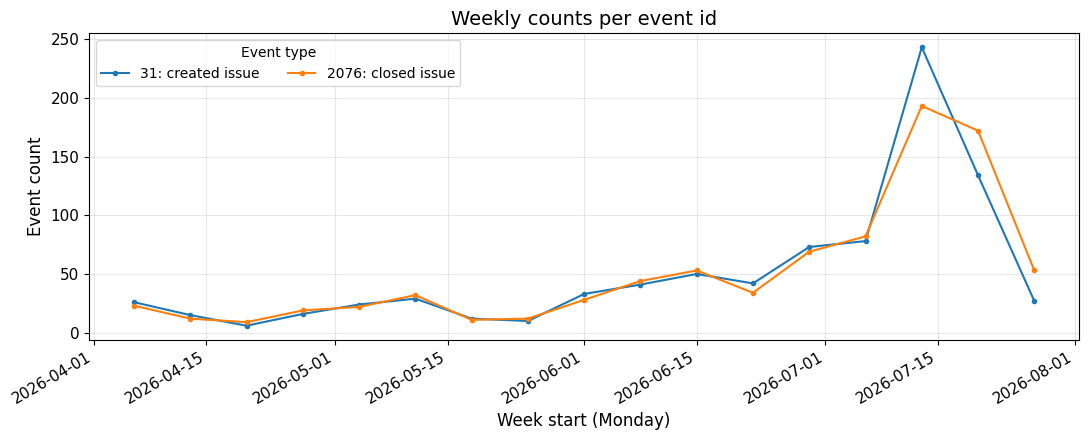

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Vibe-Trading\weekly_open_closed_summary.csv


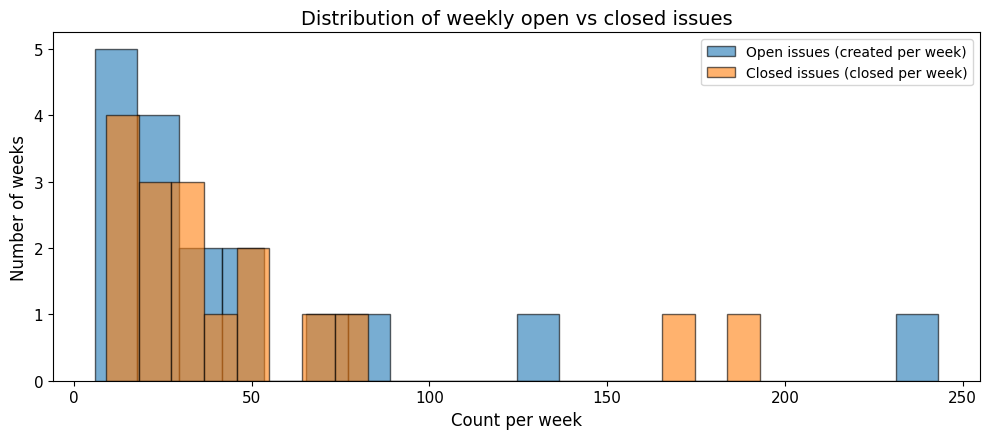

,Open issues (weekly created),Closed issues (weekly closed)
count,17.00,17.00
mean,50.53,51.06
std,58.97,53.84
min,6.00,9.00
25%,16.00,19.00
50%,29.00,32.00
75%,50.00,53.00
max,243.00,193.00


In [1]:
import sys
from pathlib import Path

root = Path.cwd().resolve()
if not (root / "functions").exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("Vibe-Trading")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_no_titles_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR for detecting the anomalies 


In [2]:
from functions.anomaly import rolling_iqr_detect
from functions.config import IQR_CONFIG

rolling_iqr_anomalies = rolling_iqr_detect(
    weekly[cfg.closed_event_type_id],
    **IQR_CONFIG,
)
rolling_iqr_anomalies.to_csv(cfg.tables_dir / "rolling_iqr_anomalies.csv", index=False)
print(
    f"Detected {int(rolling_iqr_anomalies['is_anomaly'].sum())} "
    f"rolling-IQR anomalies for event_type_id={cfg.closed_event_type_id}."
)
rolling_iqr_anomalies.head()


Detected 6 rolling-IQR anomalies for event_type_id=2076.


,week_start,value,rolling_q1,rolling_q3,iqr,lower_bound,upper_bound,is_anomaly,anomaly_direction,anomaly_score
0,2026-04-06,23,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
1,2026-04-13,12,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
2,2026-04-20,9,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
3,2026-04-27,19,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
4,2026-05-04,22,NaN,NaN,NaN,NaN,NaN,False,normal,0.0


## 3. Export anomaly object / event IDs


In [3]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(
    rolling_iqr_anomalies, eventsPerobj_df, cfg
)
anomaly_object_ids.head()



,week_start,object_id
0,2026-07-20,43771
1,2026-07-13,44174
2,2026-07-13,44559
3,2026-07-13,45068
4,2026-07-20,45264


## 4. Anomaly plots


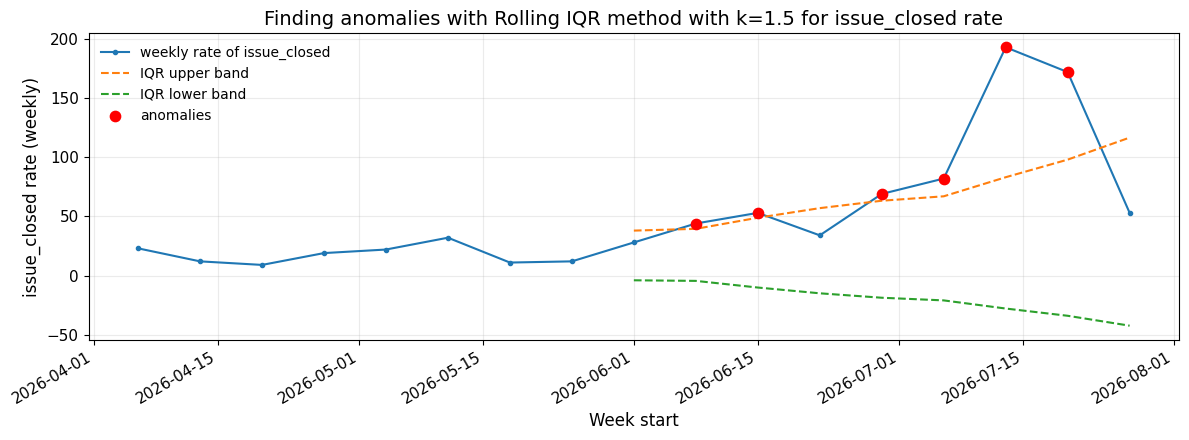

C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


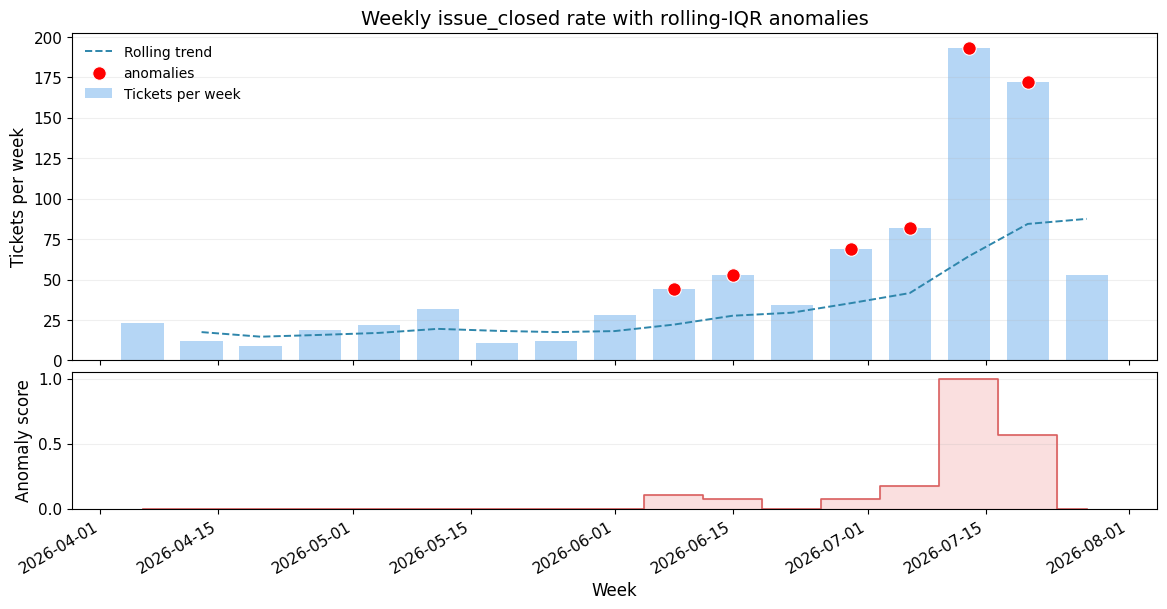

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/Vibe-Trading')

In [4]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(rolling_iqr_anomalies, cfg)


## 5. Commit context and type classification

Link commits to issues that closed in anomaly weeks via the same `event_id` join as 8b. Classify those messages for the weekly stacked plot, and save overlapping `anomaly_issue_commit_categories`.


commit_context summary: 6 rows x 17 columns
Saved commit_context to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Vibe-Trading\commit_context.csv

=== Anomaly issue commit categories (overlapping, event_id link) ===
Anomaly issues: 611
Issues with classified commits: 441
Issues with no classified commit (assigned to other): 170
Issues in more than one category: 90
  feature_work  101
  bug_fixes     287
  tech_debt     111
  docs          30
  other         227
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Vibe-Trading\anomaly_issue_commit_categories.csv
commit_typeclass_per_week summary: 6 rows x 33 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.264
  bug_fixes     0.387
  tech_debt     0.165
  docs          0.047
  other         0.137

Mean category ratios by anomaly_direction:
  

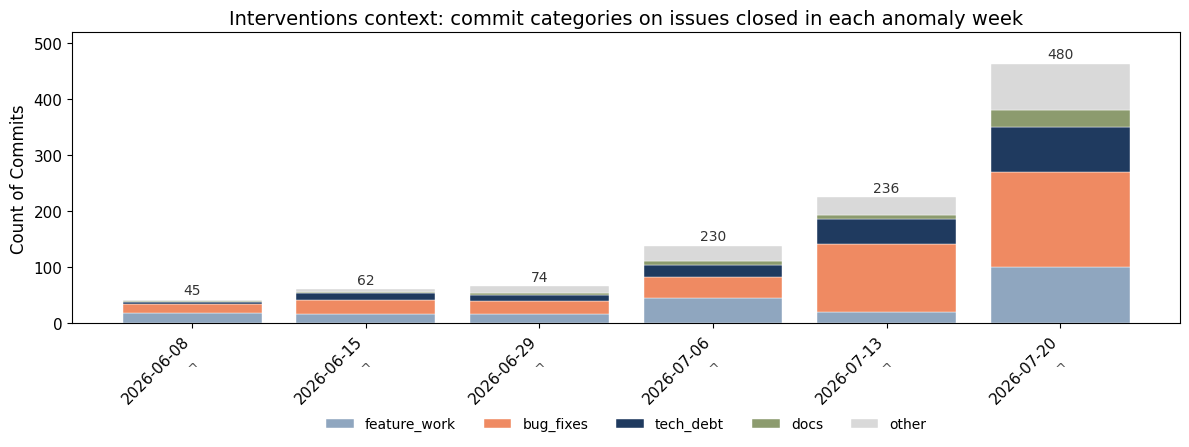

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/Vibe-Trading')

In [5]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join, anomaly_issue_commit_categories = build_commit_context(
    rolling_iqr_anomalies, eventsPerobj_df, objects_attributes, cfg, anomaly_object_ids
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log: viewpoint of issues


In [6]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 12905 events, 859 cases
  case:concept:name concept:name            time:timestamp
0             10192    committed 2026-07-20 10:31:33+00:00
1             10192    committed 2026-07-20 10:31:33+00:00
2             10192    committed 2026-07-20 10:32:08+00:00
3             10192    committed 2026-07-20 10:33:20+00:00
4             10192    committed 2026-07-20 10:37:45+00:00
5             10192    committed 2026-07-20 10:39:21+00:00
6             10192    committed 2026-07-20 10:42:41+00:00
7             10192    committed 2026-07-20 10:44:45+00:00
8             10192    committed 2026-07-20 10:45:20+00:00
9             10192    committed 2026-07-20 10:48:32+00:00


## 7a. Category-log preprocess 

Clean the raw step-6 `flat` log for commit-category discovery: keep cases that contain `closed` or `head_ref_deleted` anywhere (full traces), then drop traces with any activity repeating more than `CATEGORY_MAX_REP` times. Independent of step 8 (`MAX_REP=5`).


In [7]:
from functions.preprocessing import preprocess_flat_log

CATEGORY_MAX_REP = 1000
flat_df_category_clean = preprocess_flat_log(flat, cfg, max_rep=CATEGORY_MAX_REP) 


=== Category-log preprocess (contain=closed/head_ref_deleted, max_rep=1000) ===
Raw: 859 cases | 12905 events
After contain-end filter: 859 cases | 12905 events
After max_rep=1000: 859 cases | 12905 events


In [8]:
from functions.discovery import select_miners

# Available: alpha_classic, inductive_IM, heuristics_dep_0.5/0.6/0.7,
# inductive_IMf_noise_0.2/0.3/0.4, split_miner_eps_*_eta_*
# None runs all miners.
DISCOVERY_MINERS = [
    "inductive_IMf_noise_0.2",
    "split_miner_eps_0.2_eta_0.5",
    "heuristics_dep_0.5",
]


## 7b. Commit-category event logs (8a cleaned flat) and discovery in each action category

Classify every commit message and put each case from `flat_df_category_clean` into exactly one category log: if all of its commits share a category it stays there; if they span several categories (or it has no classified commit) it goes to `other`. Logs are disjoint. Then run discovery F1 on those five logs plus that cleaned whole log. Discovery methods come from `DISCOVERY_MINERS` in the cell after 8a (`None` runs all).


In [9]:
from functions.commits import build_whole_commit_category_logs
from functions.discovery import evaluate_clean_logs, select_miners

category_logs, issue_commit_categories, commit_classified_all = build_whole_commit_category_logs(
    flat_df_category_clean, eventsPerobj_df, objects_attributes, cfg
)

commit_category_log_groups_df = {**category_logs, "whole": flat_df_category_clean}

consolidated_results_table_commit_categories, commit_category_log_groups_eventlog, _ = evaluate_clean_logs(
    commit_category_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_commit_categories.csv"
)
canonical_whole_rows = consolidated_results_table_commit_categories[
    consolidated_results_table_commit_categories["log_name"] == "whole"
].copy()
consolidated_results_table_commit_categories.head()


=== Commit message classification (preprocessed whole log) ===
Preprocessed whole-log cases: 859
Classified unique commits: 5851
  feature_work  730
  bug_fixes     2193
  tech_debt     758
  docs          546
  other         1624
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Vibe-Trading\commit_classified_all.csv

=== Issue commit categories (disjoint, preprocessed whole log) ===
Whole-log cases: 859
Issues with classified commits: 614
Issues with no classified commit (assigned to other): 245
Issues with mixed commit categories (assigned to other): 152
Issues in issue_commit_categories: 859
  feature_work  74
  bug_fixes     265
  tech_debt     81
  docs          20
  other         419
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Vibe-Trading\issue_commit_categories.csv

=== Preprocessed-log commit-ca

c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 546/546 [00:01<00:00, 290.26it/s]

Expected records: 18 | Observed: 18

7) Consolidated results table in clean logs
        log_name             discovery_method  n_cases  avg_cycle_time_days  \
0      bug_fixes           heuristics_dep_0.5      265            18.768220   
1           docs           heuristics_dep_0.5       20            31.240664   
2   feature_work           heuristics_dep_0.5       74            26.407151   
3          other           heuristics_dep_0.5      419            22.005222   
4      tech_debt           heuristics_dep_0.5       81            13.405476   
5          whole           heuristics_dep_0.5      859            20.789933   
6      bug_fixes      inductive_IMf_noise_0.2      265            18.768220   
7           docs      inductive_IMf_noise_0.2       20            31.240664   
8   feature_work      inductive_IMf_noise_0.2       74            26.407151   
9          other      inductive_IMf_noise_0.2      419            22.005222   
10     tech_debt      inductive_IMf_noise_0.2     

,log_name,discovery_method,n_cases,avg_cycle_time_days,avg_trace_length,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,bug_fixes,heuristics_dep_0.5,265,18.768220,8.573585,0.545640,0.833584,0.840866,0.837209,317.0,19.0,0.482625,ok,None
1,docs,heuristics_dep_0.5,20,31.240664,7.900000,0.406011,0.901149,0.637076,0.746445,184.0,10.0,0.562044,ok,None
2,feature_work,heuristics_dep_0.5,74,26.407151,9.081081,0.521873,0.885382,0.711027,0.788683,230.0,13.0,0.486631,ok,None
3,other,heuristics_dep_0.5,419,22.005222,21.248210,0.536663,0.941118,0.188969,0.314740,582.0,32.0,0.441118,ok,None
4,tech_debt,heuristics_dep_0.5,81,13.405476,11.111111,0.514468,0.894053,0.489531,0.632656,275.0,9.0,0.500000,ok,None


## 7c. Anomaly vs normal logs from cleaned flat, then discovery F1

Split `flat_df_category_clean` by anomaly object IDs from step 3: keep matching cases as the anomaly log and the rest as the normal log. Then run discovery F1 on anomaly and normal using `DISCOVERY_MINERS`. Whole-log F1 is copied from 7b (`canonical_whole_rows`), not rediscovered.


In [10]:
from functions.ocel_flatten import split_flat_by_anomaly_object_ids
from functions.discovery import evaluate_clean_logs, select_miners
import pandas as pd

anomaly_log_df, normal_log_df = split_flat_by_anomaly_object_ids(
    flat_df_category_clean, anomaly_object_ids
)

anomaly_normal_log_groups_df = {
    "anomaly": anomaly_log_df,
    "normal": normal_log_df,
}

consolidated_results_table_anomaly_normal, _, _ = evaluate_clean_logs(
    anomaly_normal_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_anomaly_normal.csv",
)
consolidated_results_table_anomaly_normal = pd.concat(
    [consolidated_results_table_anomaly_normal, canonical_whole_rows],
    ignore_index=True,
).sort_values(["discovery_method", "log_name"]).reset_index(drop=True)
consolidated_results_table_anomaly_normal.to_csv(
    cfg.tables_dir / "consolidated_results_table_anomaly_normal.csv",
    index=False,
)
anomaly_normal_log_groups_df["whole"] = flat_df_category_clean
consolidated_results_table_anomaly_normal


Anomaly log: 611 cases | 5931 events
Normal log: 248 cases | 6974 events


replaying log with TBR, completed traces :: 100%|██████████| 546/546 [00:01<00:00, 273.90it/s]

Expected records: 9 | Observed: 9

7) Consolidated results table in clean logs
  log_name             discovery_method  n_cases  avg_cycle_time_days  \
0  anomaly           heuristics_dep_0.5      611            13.911690   
1   normal           heuristics_dep_0.5      248            37.735925   
2    whole           heuristics_dep_0.5      859            20.789933   
3  anomaly      inductive_IMf_noise_0.2      611            13.911690   
4   normal      inductive_IMf_noise_0.2      248            37.735925   
5    whole      inductive_IMf_noise_0.2      859            20.789933   
6  anomaly  split_miner_eps_0.2_eta_0.5      611            13.911690   
7   normal  split_miner_eps_0.2_eta_0.5      248            37.735925   
8    whole  split_miner_eps_0.2_eta_0.5      859            20.789933   

   avg_trace_length  generalization   fitness  precision   f_score   size  \
0          9.707038        0.541911  0.890820   0.433036  0.582778  480.0   
1         28.120968        0.509733 

,log_name,discovery_method,n_cases,avg_cycle_time_days,avg_trace_length,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,anomaly,heuristics_dep_0.5,611,13.911690,9.707038,0.541911,0.890820,0.433036,0.582778,480.0,19.0,0.462687,ok,None
1,normal,heuristics_dep_0.5,248,37.735925,28.120968,0.509733,0.945212,0.329307,0.488443,546.0,32.0,0.454545,ok,None
2,whole,heuristics_dep_0.5,859,20.789933,15.023283,0.563092,0.903420,0.247845,0.388977,626.0,35.0,0.442379,ok,None
3,anomaly,inductive_IMf_noise_0.2,611,13.911690,9.707038,0.817708,0.970536,0.326037,0.488103,288.0,8.0,0.636364,ok,None
4,normal,inductive_IMf_noise_0.2,248,37.735925,28.120968,0.813531,0.999248,0.086183,0.158679,229.0,3.0,0.614907,ok,None
5,whole,inductive_IMf_noise_0.2,859,20.789933,15.023283,0.824706,0.991284,0.181289,0.306520,276.0,4.0,0.625000,ok,None
6,anomaly,split_miner_eps_0.2_eta_0.5,611,13.911690,9.707038,0.772593,0.811580,0.601015,0.690604,361.0,54.0,0.404908,ok,None
7,normal,split_miner_eps_0.2_eta_0.5,248,37.735925,28.120968,0.729323,0.862166,0.428905,0.572838,407.0,104.0,0.330073,ok,None
8,whole,split_miner_eps_0.2_eta_0.5,859,20.789933,15.023283,0.796337,0.953984,0.411950,0.575421,292.0,6.0,0.535714,ok,None


## 7d. Anomaly x commit-category logs, then discovery F1

Cross `anomaly_log_df` / `normal_log_df` from 8c with disjoint `category_logs` from 8b: each case belongs to exactly one category, then those logs are split into anomaly vs normal. Then run discovery F1 on the ten combined groups using `DISCOVERY_MINERS`. Whole-log F1 is copied from 7b (`canonical_whole_rows`), not rediscovered.


In [11]:
from functions.discovery import evaluate_clean_logs, select_miners
import pandas as pd

anomaly_ids = set(anomaly_log_df["case:concept:name"].astype(str))
normal_ids = set(normal_log_df["case:concept:name"].astype(str))

anomaly_category_log_groups_df = {
    **{f"anomaly_{name}": df[df["case:concept:name"].astype(str).isin(anomaly_ids)].copy()
       for name, df in category_logs.items()},
    **{f"normal_{name}": df[df["case:concept:name"].astype(str).isin(normal_ids)].copy()
       for name, df in category_logs.items()},
}

consolidated_results_table_anomaly_categories, _, _ = evaluate_clean_logs(
    anomaly_category_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_anomaly_categories.csv",
)
consolidated_results_table_anomaly_categories = pd.concat(
    [consolidated_results_table_anomaly_categories, canonical_whole_rows],
    ignore_index=True,
).sort_values(["discovery_method", "log_name"]).reset_index(drop=True)
consolidated_results_table_anomaly_categories.to_csv(
    cfg.tables_dir / "consolidated_results_table_anomaly_categories.csv",
    index=False,
)
consolidated_results_table_anomaly_categories


replaying log with TBR, completed traces :: 100%|██████████| 546/546 [00:01<00:00, 300.00it/s]

Expected records: 33 | Observed: 33

7) Consolidated results table in clean logs
                log_name             discovery_method  n_cases  \
0      anomaly_bug_fixes           heuristics_dep_0.5      214   
1           anomaly_docs           heuristics_dep_0.5        7   
2   anomaly_feature_work           heuristics_dep_0.5       52   
3          anomaly_other           heuristics_dep_0.5      273   
4      anomaly_tech_debt           heuristics_dep_0.5       65   
5       normal_bug_fixes           heuristics_dep_0.5       51   
6            normal_docs           heuristics_dep_0.5       13   
7    normal_feature_work           heuristics_dep_0.5       22   
8           normal_other           heuristics_dep_0.5      146   
9       normal_tech_debt           heuristics_dep_0.5       16   
10                 whole           heuristics_dep_0.5      859   
11     anomaly_bug_fixes      inductive_IMf_noise_0.2      214   
12          anomaly_docs      inductive_IMf_noise_0.2        

,log_name,discovery_method,n_cases,avg_cycle_time_days,avg_trace_length,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,anomaly_bug_fixes,heuristics_dep_0.5,214,13.425263,8.144860,0.598430,0.872614,0.794517,0.831736,231.0,13.0,0.494624,ok,None
1,anomaly_docs,heuristics_dep_0.5,7,22.945924,8.285714,0.242057,0.951456,0.616071,0.747885,134.0,0.0,0.648352,ok,None
2,anomaly_feature_work,heuristics_dep_0.5,52,17.082125,8.980769,0.555814,0.916400,0.664646,0.770479,185.0,7.0,0.500000,ok,None
3,anomaly_other,heuristics_dep_0.5,273,13.573801,10.699634,0.501069,0.910661,0.359438,0.515435,474.0,26.0,0.446914,ok,None
4,anomaly_tech_debt,heuristics_dep_0.5,65,13.423029,11.415385,0.554302,0.901801,0.446554,0.597325,242.0,8.0,0.515789,ok,None
5,normal_bug_fixes,heuristics_dep_0.5,51,41.187686,10.372549,0.479461,0.859614,0.647226,0.738452,284.0,22.0,0.482759,ok,None
6,normal_docs,heuristics_dep_0.5,13,35.707062,7.692308,0.419792,0.872552,0.825806,0.848536,121.0,6.0,0.604651,ok,None
7,normal_feature_work,heuristics_dep_0.5,22,48.448120,9.318182,0.449014,0.901587,0.704453,0.790921,190.0,10.0,0.500000,ok,None
8,normal_other,heuristics_dep_0.5,146,37.770824,40.972603,0.473123,0.964900,0.243031,0.388268,487.0,26.0,0.458537,ok,None
9,normal_tech_debt,heuristics_dep_0.5,16,13.334166,9.875000,0.385612,0.890461,0.592391,0.711468,148.0,3.0,0.588785,ok,None


In [13]:
import pandas as pd

xlsx_path = cfg.tables_dir / "consolidated_results_tables.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    consolidated_results_table_commit_categories.to_excel(
        writer, sheet_name="commit_categories", index=False
    )
    consolidated_results_table_anomaly_normal.to_excel(
        writer, sheet_name="anomaly_normal", index=False
    )
    consolidated_results_table_anomaly_categories.to_excel(
        writer, sheet_name="anomaly_categories", index=False
    )
print(f"Saved {xlsx_path}")


Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Vibe-Trading\consolidated_results_tables.xlsx


## 8. Petri nets by commit category: events related to each commit category


the question:

    what process is discovered for each disjoint commit category in the preprocessed whole log?

the input:

    category_logs from step 8b (disjoint category subsets of flat_df_category_clean)

the output:

    petri net per category log (inductive_IMf_noise_0.2)


In [14]:
#graphviz path 
import os
from pathlib import Path
import shutil

GRAPHVIZ_BIN = Path(r"C:\Program Files\Graphviz\bin")  # change if yours is elsewhere

if not (GRAPHVIZ_BIN / "dot.exe").exists():
    raise FileNotFoundError(
        f"dot.exe not found in {GRAPHVIZ_BIN}. "
        "Install Graphviz and set GRAPHVIZ_BIN to its bin folder."
    )

os.environ["PATH"] = str(GRAPHVIZ_BIN) + os.pathsep + os.environ.get("PATH", "")
print("dot found at:", shutil.which("dot"))

dot found at: C:\Program Files\Graphviz\bin\dot.EXE


feature_work


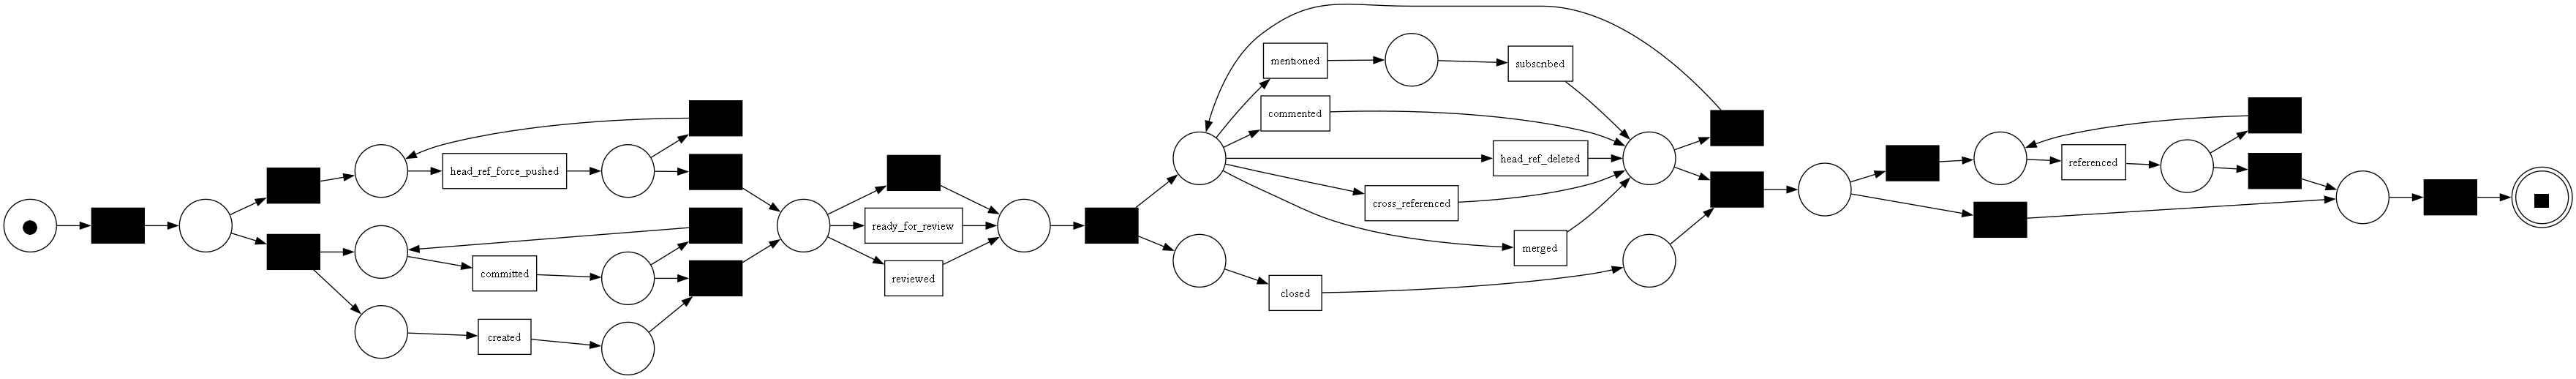

bug_fixes


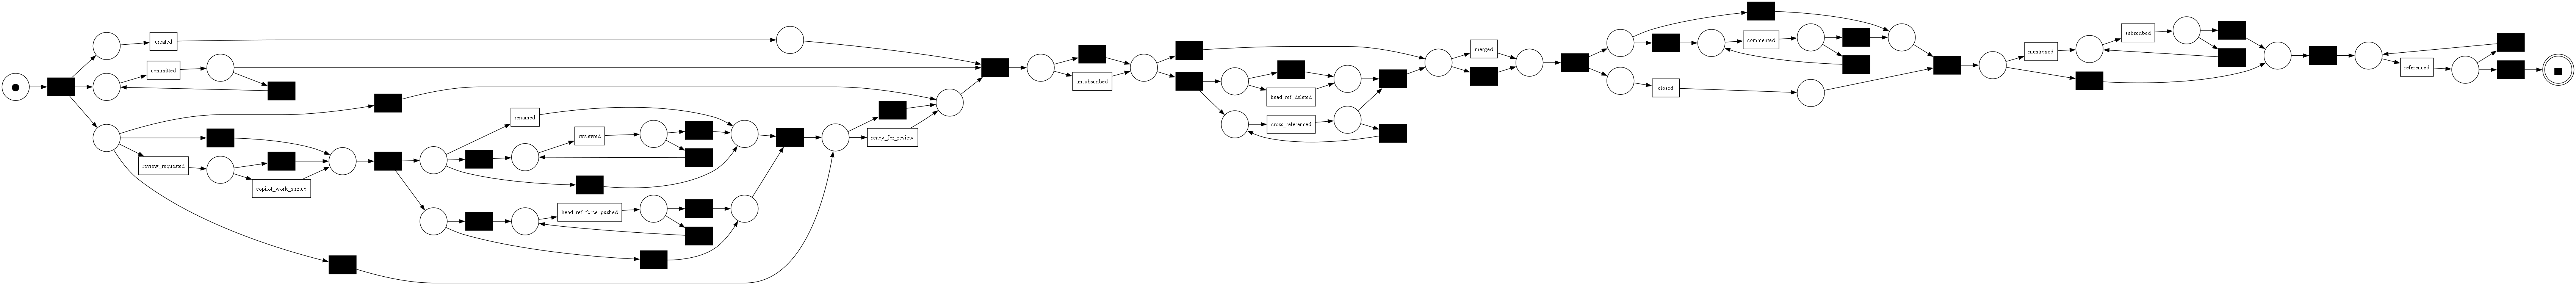

tech_debt


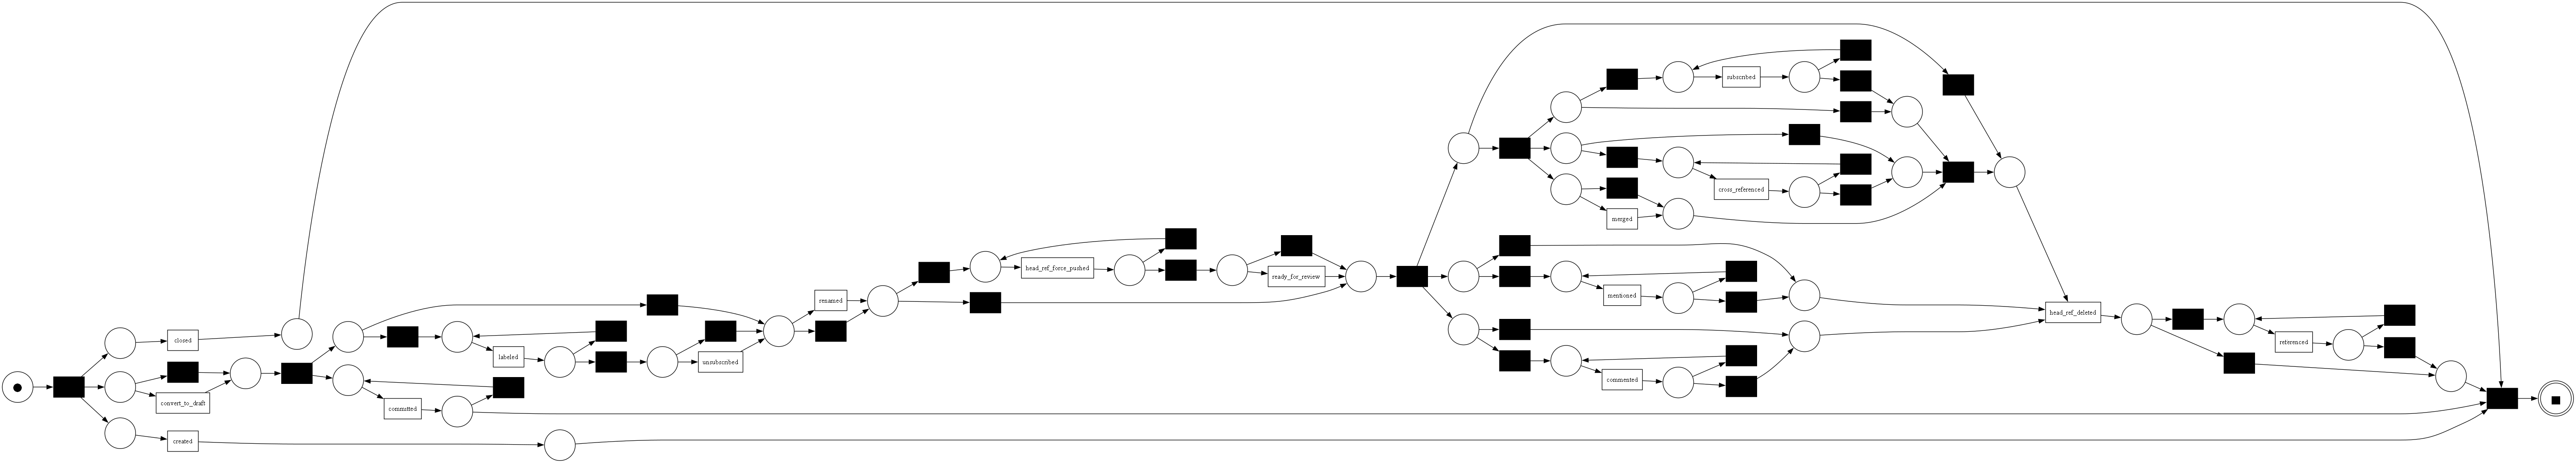

docs


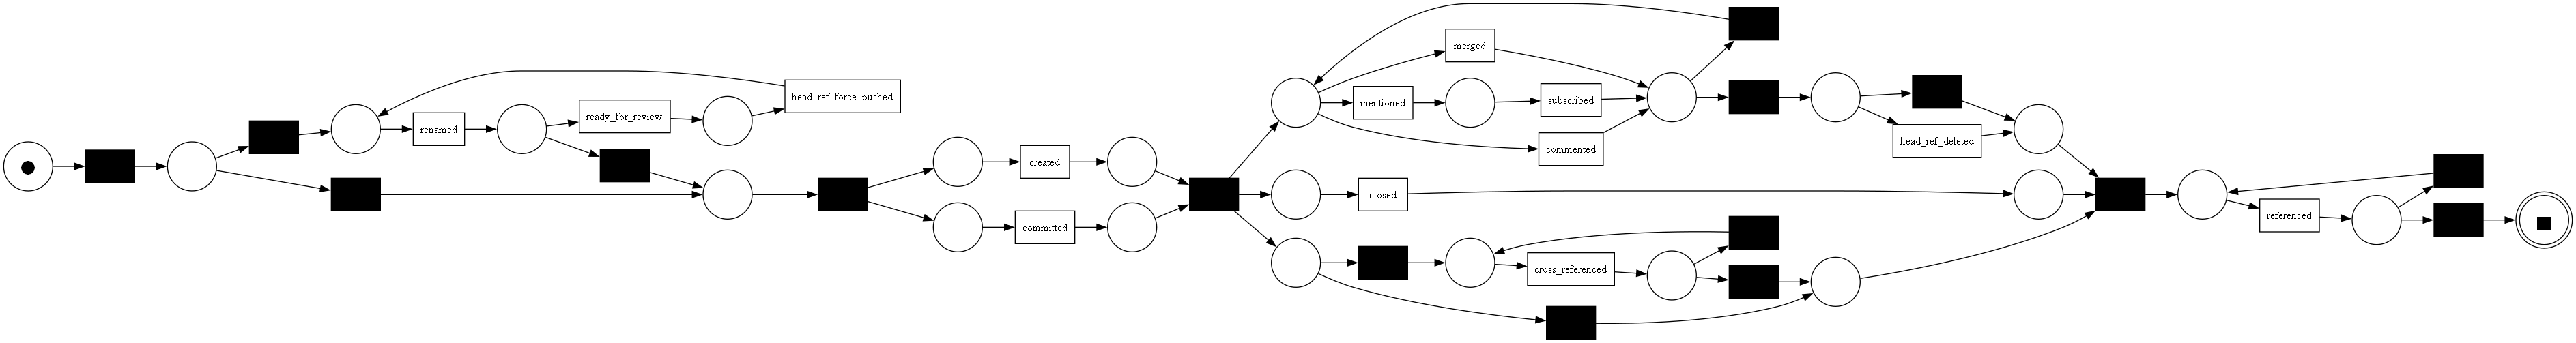

other


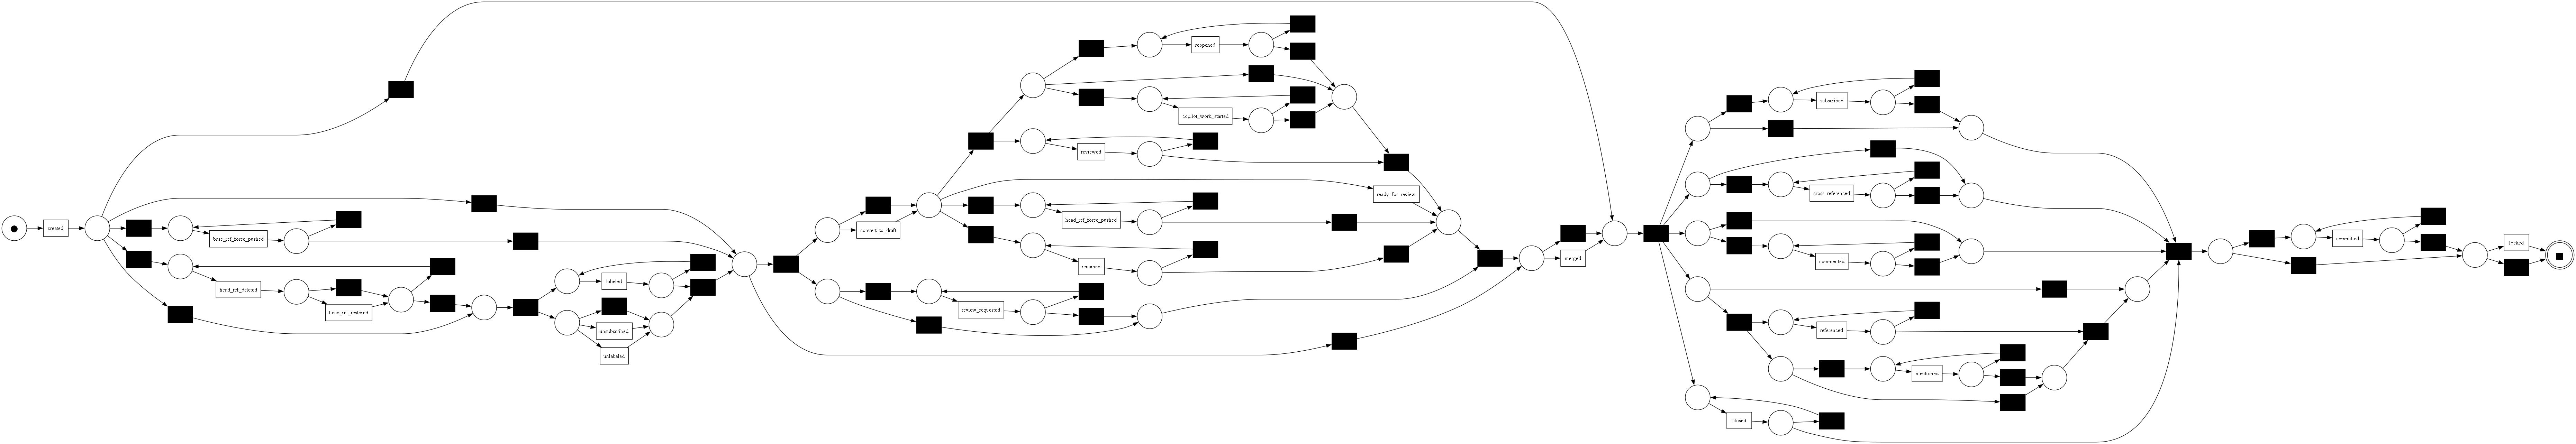

In [15]:
import pm4py
from functions.discovery import df_to_event_log, select_miners

miners = select_miners(["inductive_IMf_noise_0.2"])

for name, df in category_logs.items():
    print(name)
    elog = df_to_event_log(df)
    net, im, fm = miners["inductive_IMf_noise_0.2"](elog)
    pm4py.view_petri_net(net, im, fm)


## 9. Petri nets by anomaly, normal, and whole

the question:

    what process is discovered for anomaly vs normal vs the whole cleaned log?
    
the input:

    anomaly_normal_log_groups_df from step 8c

the output:

    petri net per log (inductive_IMf_noise_0.2)

anomaly


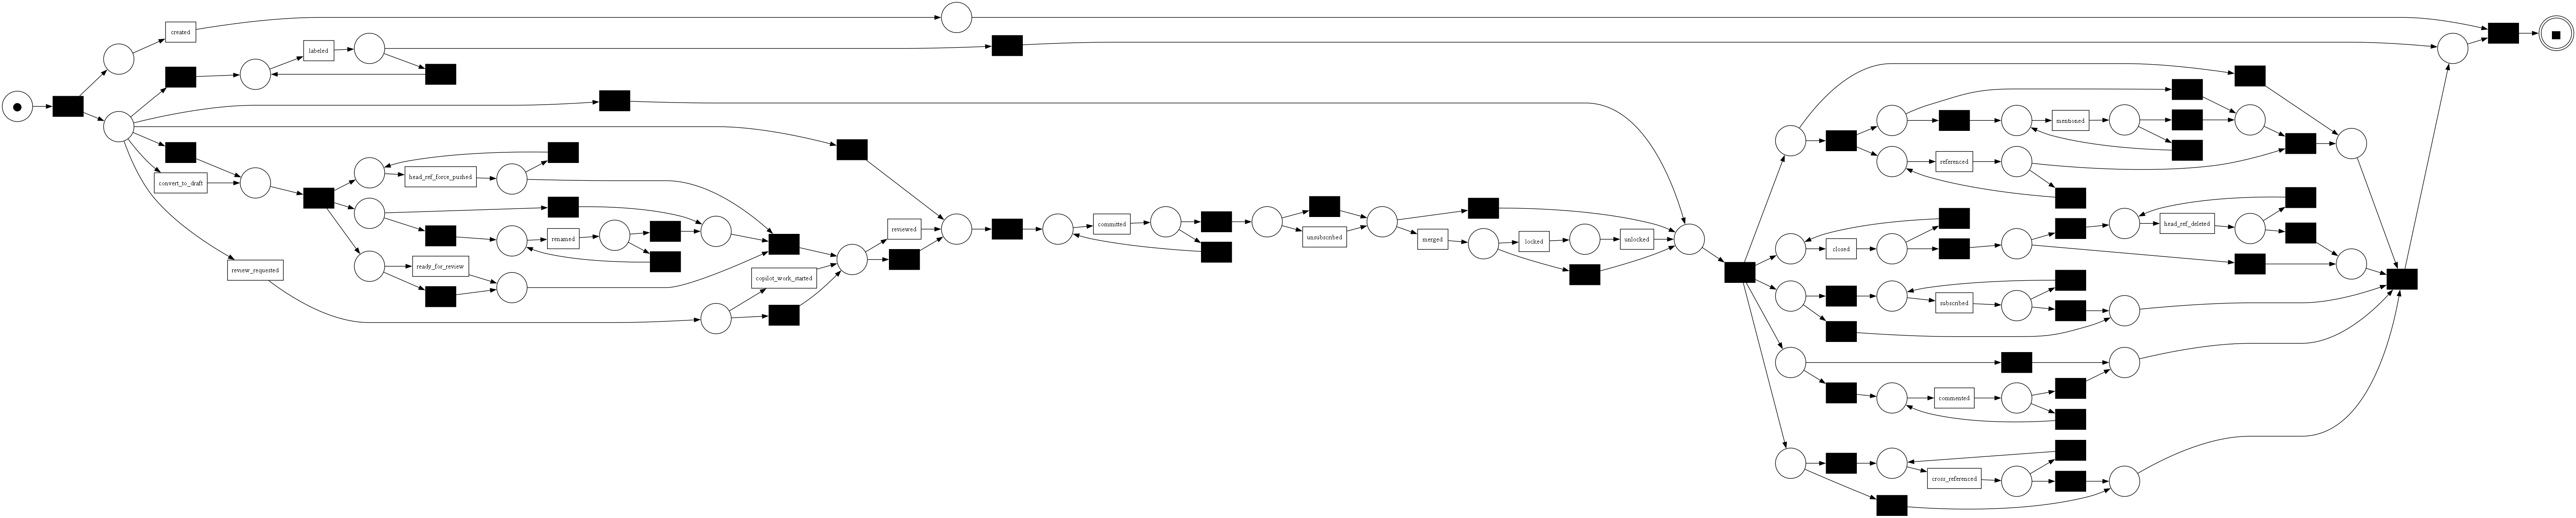

normal


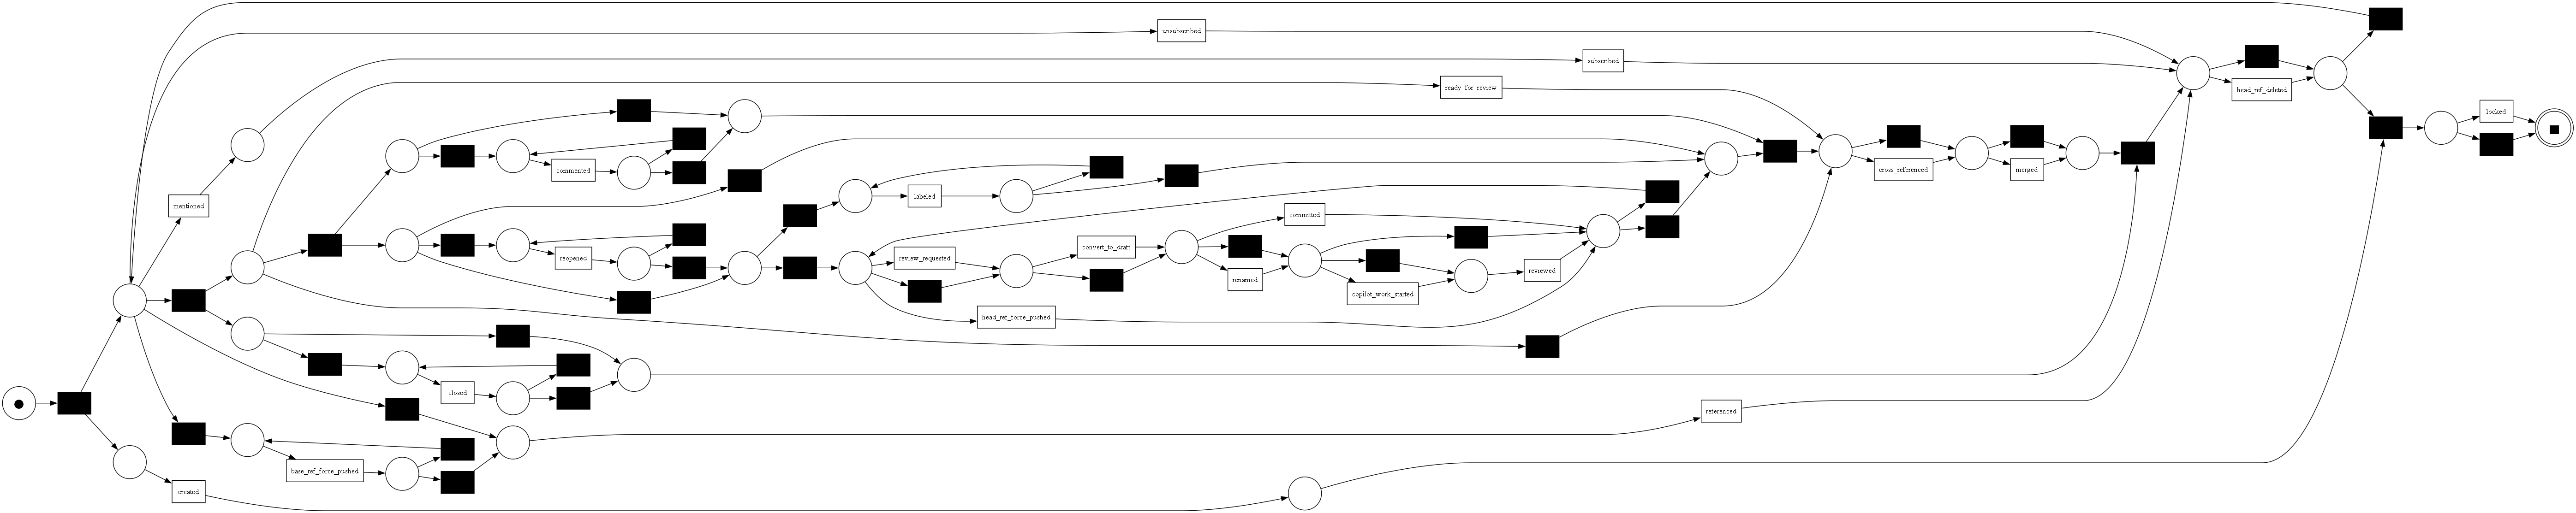

whole


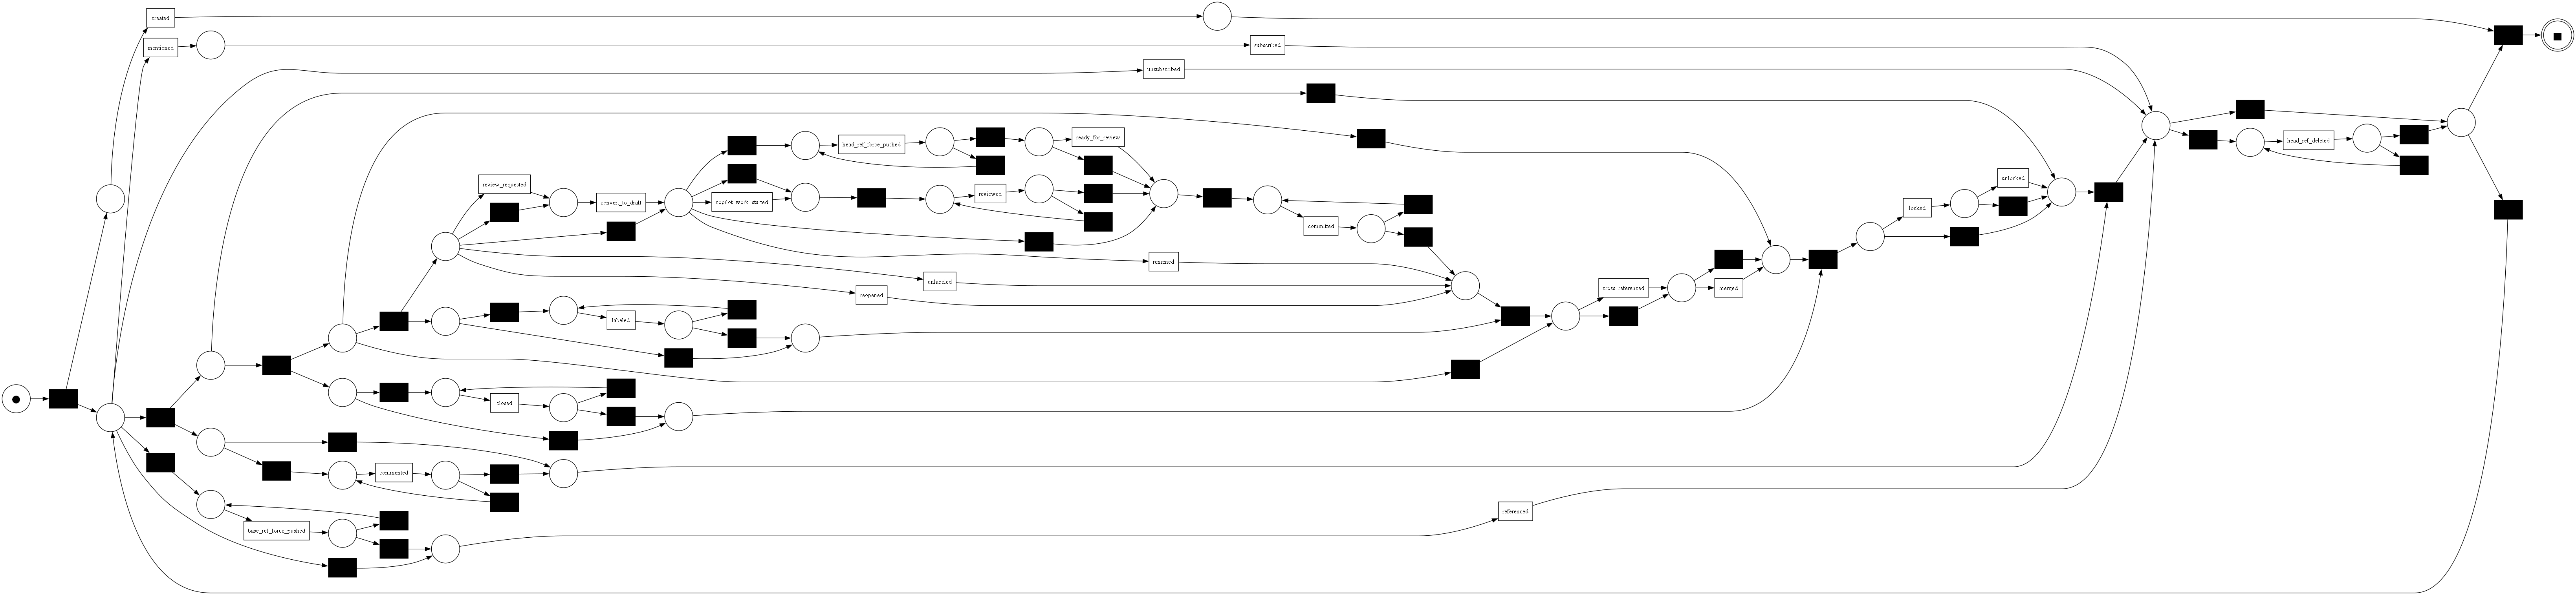

In [16]:
import pm4py
from functions.discovery import df_to_event_log, select_miners

miners = select_miners(["inductive_IMf_noise_0.2"])

for name, df in anomaly_normal_log_groups_df.items():
    print(name)
    elog = df_to_event_log(df)
    net, im, fm = miners["inductive_IMf_noise_0.2"](elog)
    pm4py.view_petri_net(net, im, fm)
